In [1]:
import pandas as pd
import numpy as np

# Dataset Overview

In [2]:
F1 = pd.read_csv('diabetes_dataset.csv')

In [3]:
F1.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
F1.shape

(100000, 31)

In [5]:
F1.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [6]:
F1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [7]:
F1['cardiovascular_history'].unique(),F1['diabetes_stage'].unique(),F1['diagnosed_diabetes'].unique()

(array([0, 1], dtype=int64),
 array(['Type 2', 'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 1'],
       dtype=object),
 array([1, 0], dtype=int64))

In [8]:
import numpy as np

# 1. Blood Pressure Ratio
F1['bp_ratio'] = F1['systolic_bp'] / F1['diastolic_bp']

# 2. Cholesterol Ratios
F1['ldl_hdl_ratio'] = F1['ldl_cholesterol'] / F1['hdl_cholesterol']
F1['total_hdl_ratio'] = F1['cholesterol_total'] / F1['hdl_cholesterol']

# 3. Glucose Features
F1['glucose_difference'] = (
    F1['glucose_postprandial'] - F1['glucose_fasting']
)

F1['glucose_ratio'] = (
    F1['glucose_postprandial'] / F1['glucose_fasting']
)



# 4. Lifestyle Score
# Normalize features first

F1['activity_norm'] = (
    F1['physical_activity_minutes_per_week']
    / F1['physical_activity_minutes_per_week'].max()
)

F1['diet_norm'] = (
    F1['diet_score']
    / F1['diet_score'].max()
)

F1['sleep_norm'] = (
    F1['sleep_hours_per_day']
    / F1['sleep_hours_per_day'].max()
)

F1['screen_norm'] = (
    F1['screen_time_hours_per_day']
    / F1['screen_time_hours_per_day'].max()
)

F1['lifestyle_score'] = (
    F1['activity_norm']
    + F1['diet_norm']
    + F1['sleep_norm']
    - F1['screen_norm']
)

# Replace infinite values if any division by zero occurred
F1.replace([np.inf, -np.inf], np.nan, inplace=True)

In [9]:
F2 = F1.drop(
    columns=[
        'physical_activity_minutes_per_week',
        'diet_score',
        'sleep_hours_per_day',
        'screen_time_hours_per_day',
        'systolic_bp',
        'diastolic_bp',
        'cholesterol_total',
        'hdl_cholesterol',
        'ldl_cholesterol',
        'glucose_fasting',
        'glucose_postprandial'
    ]
)

In [10]:
F2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           100000 non-null  int64  
 1   gender                        100000 non-null  object 
 2   ethnicity                     100000 non-null  object 
 3   education_level               100000 non-null  object 
 4   income_level                  100000 non-null  object 
 5   employment_status             100000 non-null  object 
 6   smoking_status                100000 non-null  object 
 7   alcohol_consumption_per_week  100000 non-null  int64  
 8   family_history_diabetes       100000 non-null  int64  
 9   hypertension_history          100000 non-null  int64  
 10  cardiovascular_history        100000 non-null  int64  
 11  bmi                           100000 non-null  float64
 12  waist_to_hip_ratio            100000 non-null

In [11]:
F2['ethnicity'].unique(),F2['education_level'].unique(),F2['income_level'].unique()

(array(['Asian', 'White', 'Hispanic', 'Black', 'Other'], dtype=object),
 array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
       dtype=object),
 array(['Lower-Middle', 'Middle', 'Low', 'Upper-Middle', 'High'],
       dtype=object))

In [12]:
F2['employment_status'].unique(),F2['smoking_status'].unique()

(array(['Employed', 'Unemployed', 'Retired', 'Student'], dtype=object),
 array(['Never', 'Former', 'Current'], dtype=object))

# EDA 

In [13]:
from matplotlib import pyplot as plt
import seaborn as sn

In [14]:
F2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   age                           100000 non-null  int64  
 1   gender                        100000 non-null  object 
 2   ethnicity                     100000 non-null  object 
 3   education_level               100000 non-null  object 
 4   income_level                  100000 non-null  object 
 5   employment_status             100000 non-null  object 
 6   smoking_status                100000 non-null  object 
 7   alcohol_consumption_per_week  100000 non-null  int64  
 8   family_history_diabetes       100000 non-null  int64  
 9   hypertension_history          100000 non-null  int64  
 10  cardiovascular_history        100000 non-null  int64  
 11  bmi                           100000 non-null  float64
 12  waist_to_hip_ratio            100000 non-null

In [15]:
F2.describe()

,age,alcohol_consumption_per_week,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,heart_rate,triglycerides,insulin_level,...,bp_ratio,ldl_hdl_ratio,total_hdl_ratio,glucose_difference,glucose_ratio,activity_norm,diet_norm,sleep_norm,screen_norm,lifestyle_score
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,0.219410,0.250800,0.079200,25.612653,0.856078,69.632870,121.462650,9.061242,...,1.555273,2.027440,3.587512,48.917930,1.441821,0.142751,0.599479,0.699782,0.356933,1.085079
std,15.60460,1.417779,0.413849,0.433476,0.270052,3.586705,0.046837,8.371954,43.372619,4.954060,...,0.242385,0.924405,1.025624,25.422182,0.230507,0.101332,0.178095,0.109462,0.146929,0.274078
min,18.00000,0.000000,0.000000,0.000000,0.000000,15.000000,0.670000,40.000000,30.000000,2.000000,...,0.900000,0.520833,1.093750,-45.000000,0.625000,0.000000,0.000000,0.300000,0.029762,-0.060390
25%,39.00000,1.000000,0.000000,0.000000,0.000000,23.200000,0.820000,64.000000,91.000000,5.090000,...,1.383562,1.357143,2.882159,32.000000,1.287879,0.068427,0.480000,0.630000,0.255952,0.898691
50%,50.00000,2.000000,0.000000,0.000000,0.000000,25.600000,0.860000,70.000000,121.000000,8.790000,...,1.536232,1.880000,3.437500,49.000000,1.440367,0.120048,0.600000,0.700000,0.357143,1.082909
75%,61.00000,3.000000,0.000000,1.000000,0.000000,28.000000,0.890000,75.000000,151.000000,12.450000,...,1.705128,2.514286,4.115385,66.000000,1.593985,0.192077,0.720000,0.770000,0.458333,1.268728
max,90.00000,10.000000,1.000000,1.000000,1.000000,39.200000,1.060000,105.000000,344.000000,32.220000,...,3.000000,11.300000,12.681818,153.000000,2.558442,1.000000,1.000000,1.000000,1.000000,2.238027


In [16]:
F2.shape

(100000, 30)

# :- Missing Value

In [17]:
F2.isnull().sum().sort_values(ascending=False)

age                             0
gender                          0
screen_norm                     0
sleep_norm                      0
diet_norm                       0
activity_norm                   0
glucose_ratio                   0
glucose_difference              0
total_hdl_ratio                 0
ldl_hdl_ratio                   0
bp_ratio                        0
diagnosed_diabetes              0
diabetes_stage                  0
diabetes_risk_score             0
hba1c                           0
insulin_level                   0
triglycerides                   0
heart_rate                      0
waist_to_hip_ratio              0
bmi                             0
cardiovascular_history          0
hypertension_history            0
family_history_diabetes         0
alcohol_consumption_per_week    0
smoking_status                  0
employment_status               0
income_level                    0
education_level                 0
ethnicity                       0
lifestyle_scor

# :- target distribution

In [18]:
F2['diagnosed_diabetes'].value_counts(),F2['diabetes_stage'].value_counts()

(diagnosed_diabetes
 1    59998
 0    40002
 Name: count, dtype: int64,
 diabetes_stage
 Type 2          59774
 Pre-Diabetes    31845
 No Diabetes      7981
 Gestational       278
 Type 1            122
 Name: count, dtype: int64)

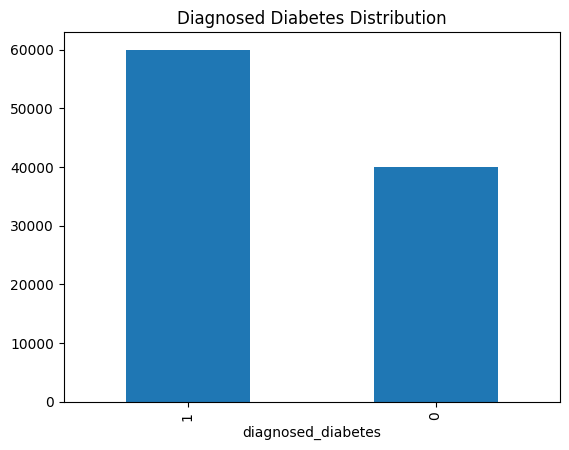

In [19]:
F2['diagnosed_diabetes'].value_counts().plot(kind='bar')
plt.title('Diagnosed Diabetes Distribution')
plt.show()

# :- Correlation Matrix

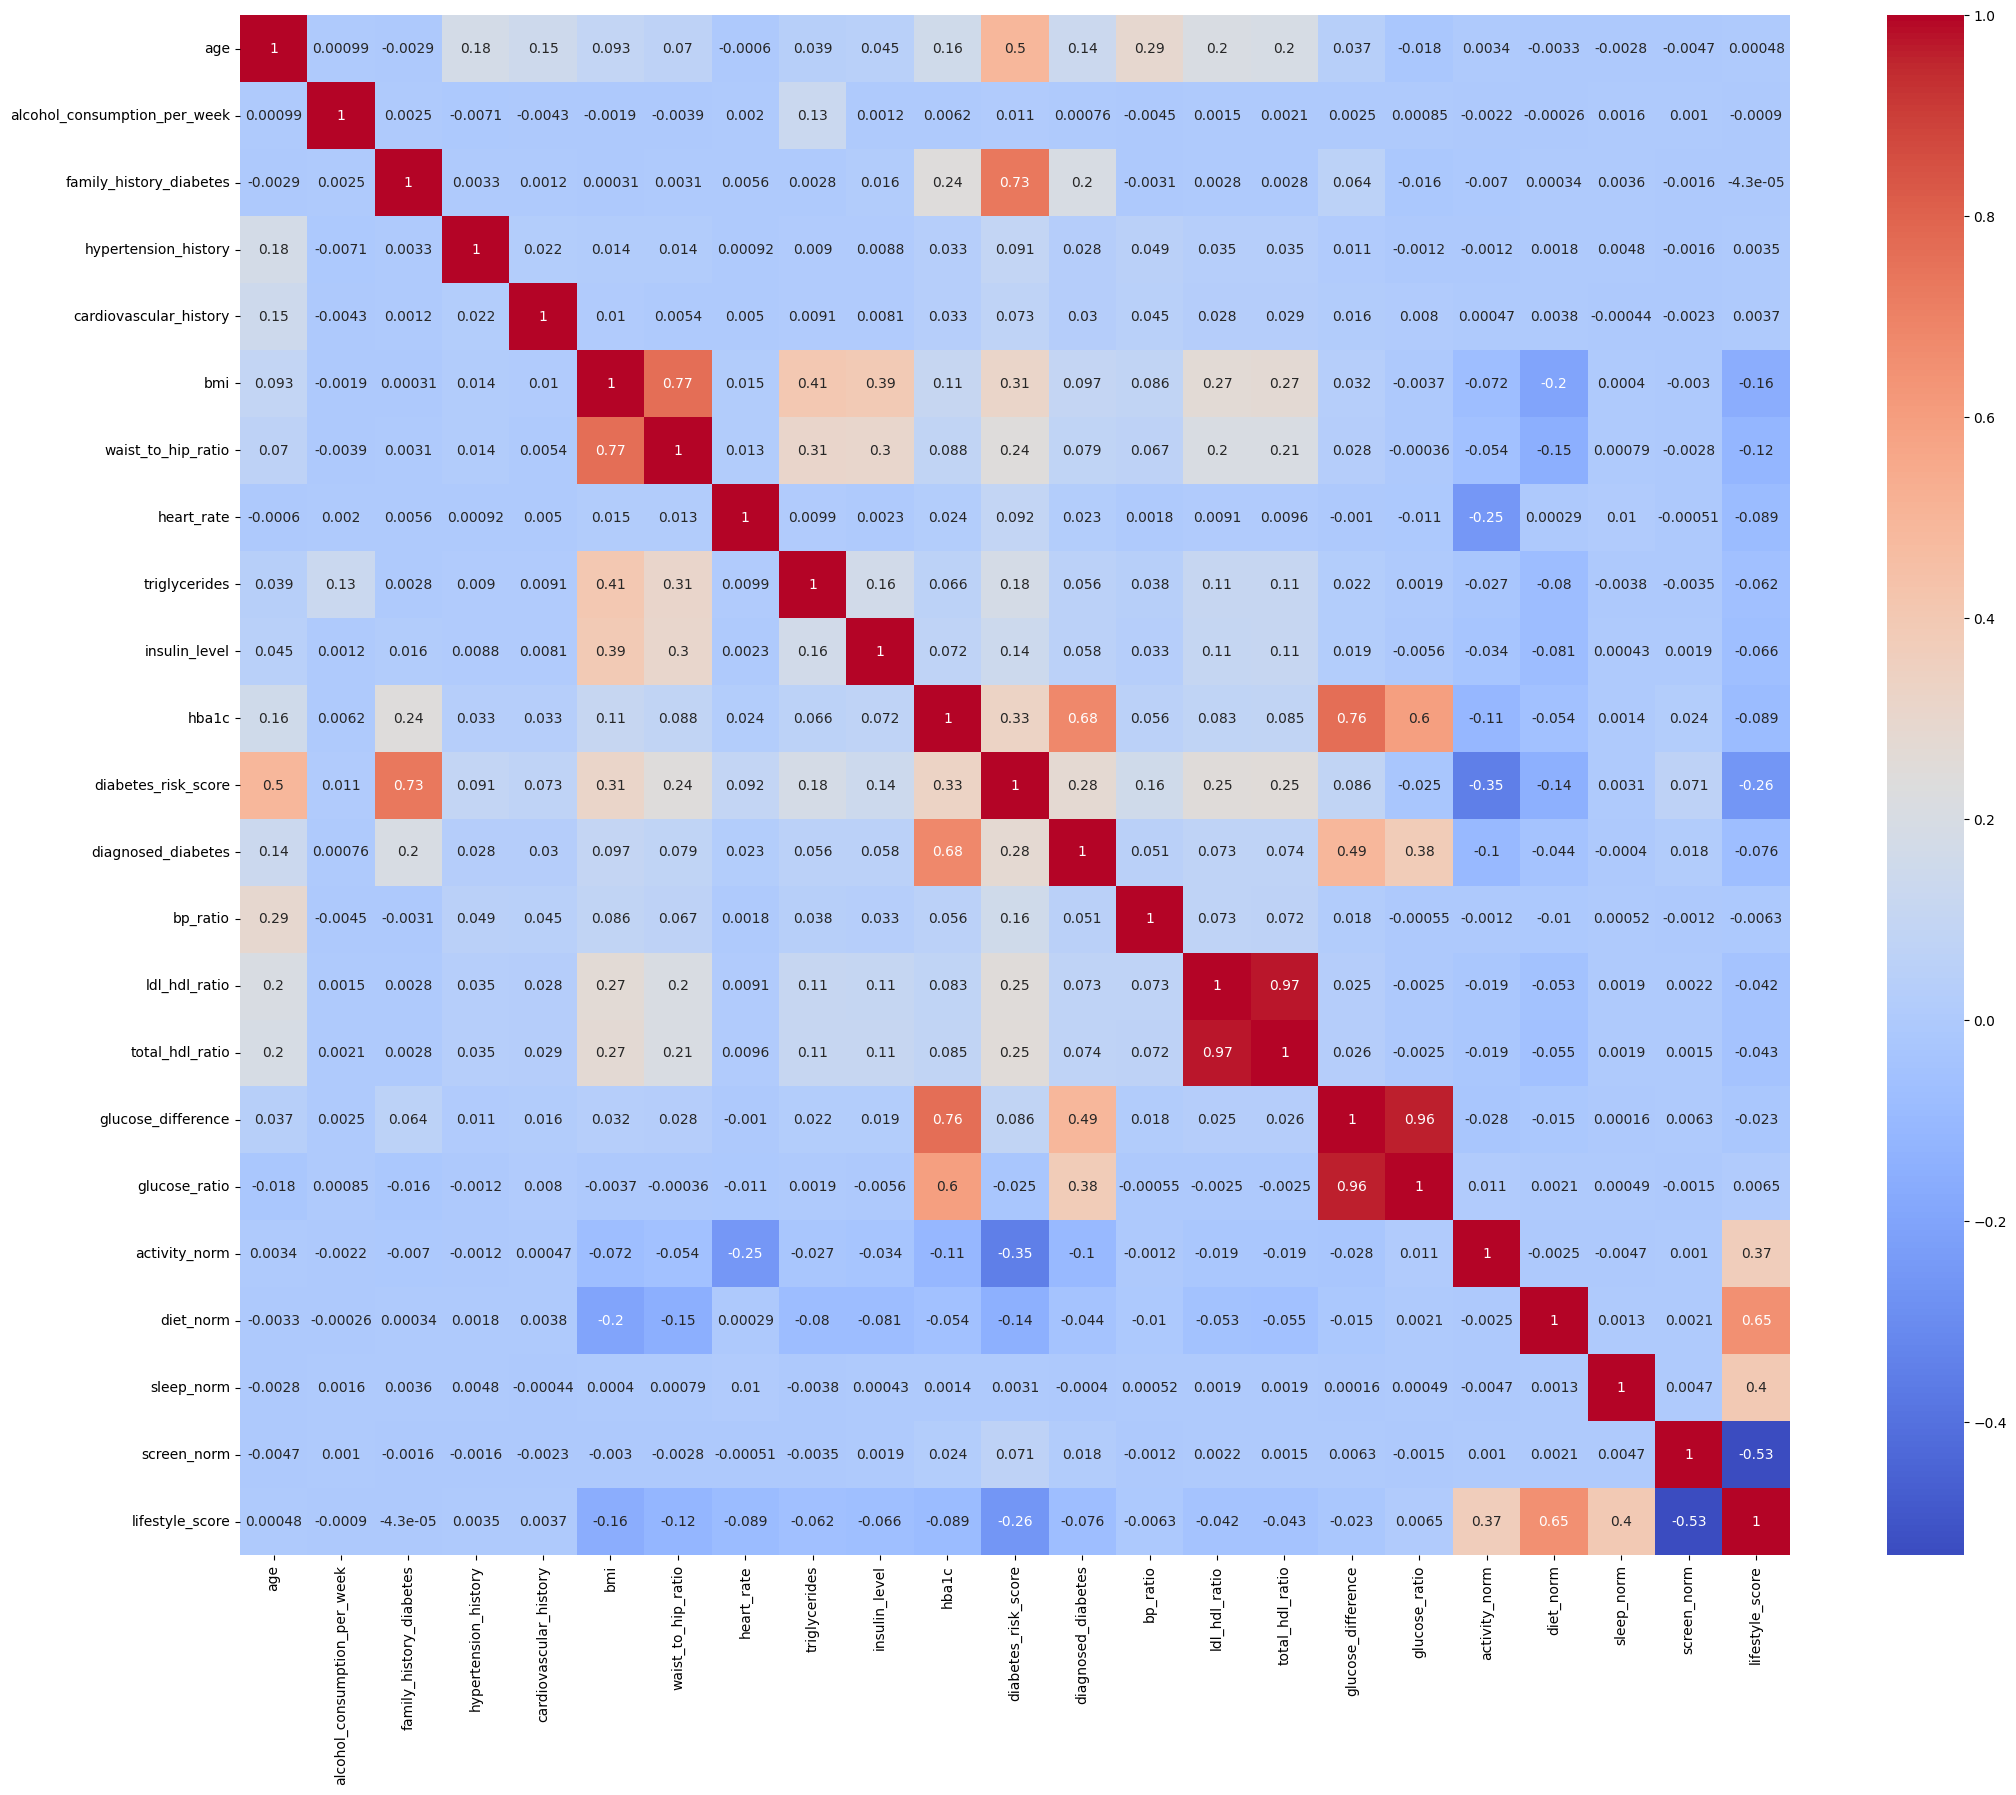

In [20]:
corr = F2.corr(numeric_only=True)
plt.figure(figsize=(25,20))
sn.heatmap(corr,cmap='coolwarm',annot=True)
plt.show()

# :- correlation with target

In [21]:
corr_target = F2.corr(numeric_only = True)['diagnosed_diabetes']
print(corr_target.sort_values(ascending = False))

diagnosed_diabetes              1.000000
hba1c                           0.679397
glucose_difference              0.493187
glucose_ratio                   0.378444
diabetes_risk_score             0.277300
family_history_diabetes         0.197926
age                             0.137713
bmi                             0.097057
waist_to_hip_ratio              0.078918
total_hdl_ratio                 0.074025
ldl_hdl_ratio                   0.072884
insulin_level                   0.057715
triglycerides                   0.056230
bp_ratio                        0.050517
cardiovascular_history          0.029793
hypertension_history            0.027524
heart_rate                      0.022785
screen_norm                     0.018127
alcohol_consumption_per_week    0.000760
sleep_norm                     -0.000399
diet_norm                      -0.044298
lifestyle_score                -0.075920
activity_norm                  -0.100774
Name: diagnosed_diabetes, dtype: float64


# :- Distribution Plot

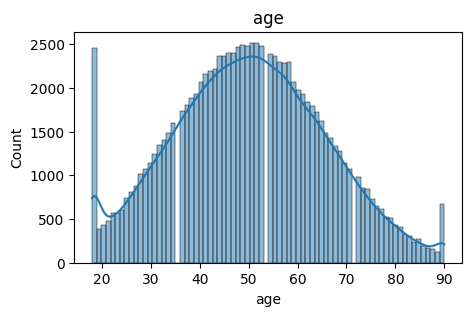

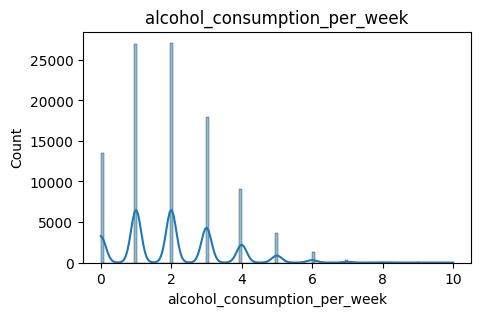

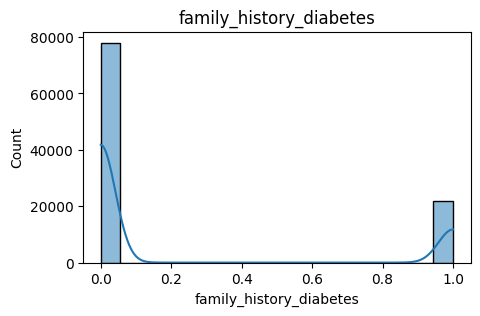

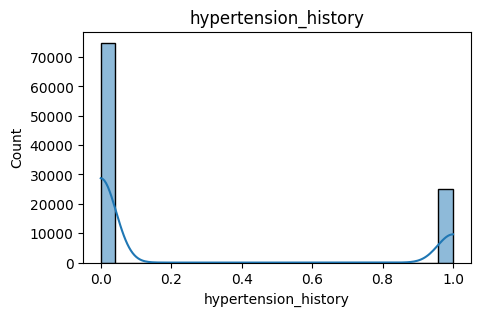

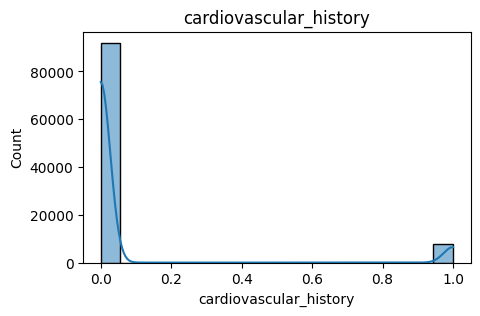

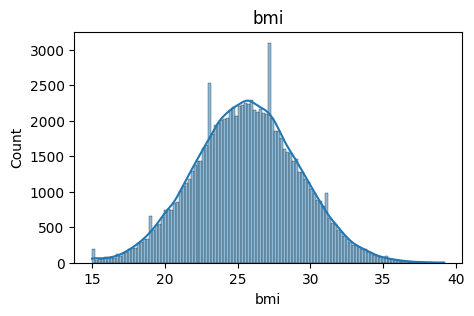

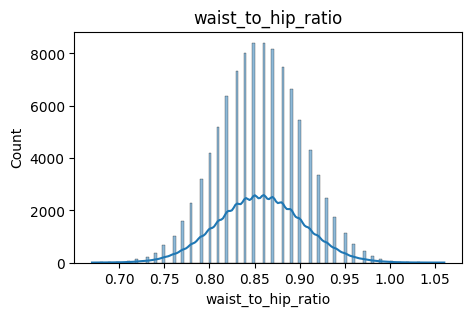

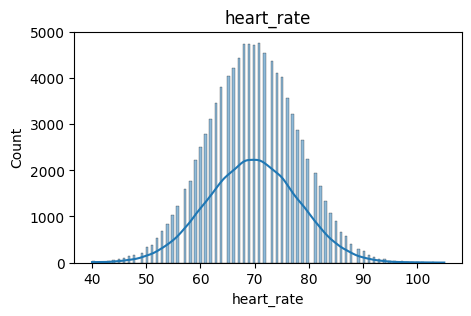

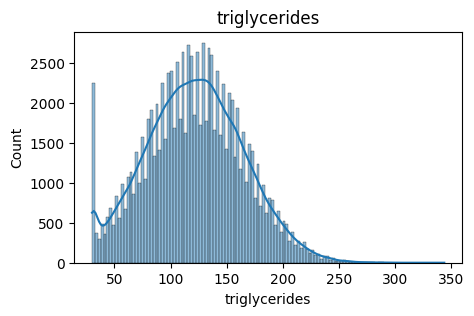

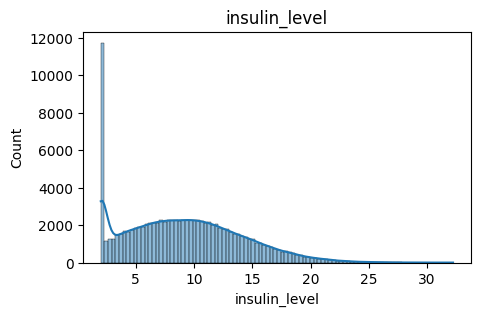

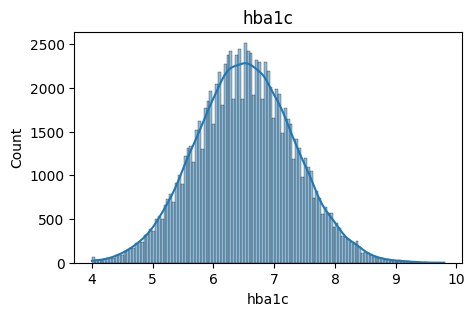

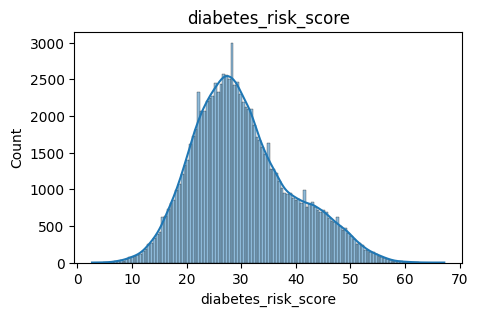

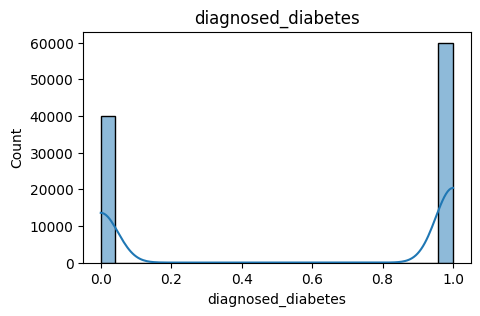

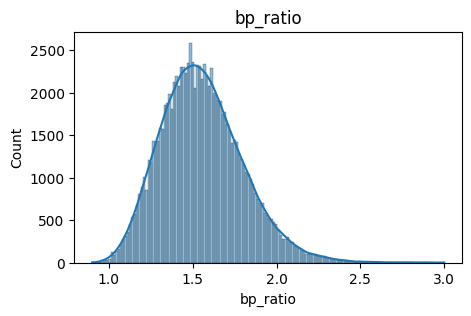

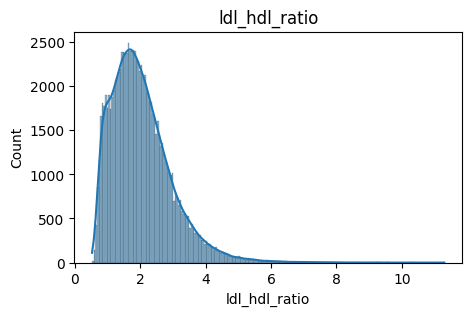

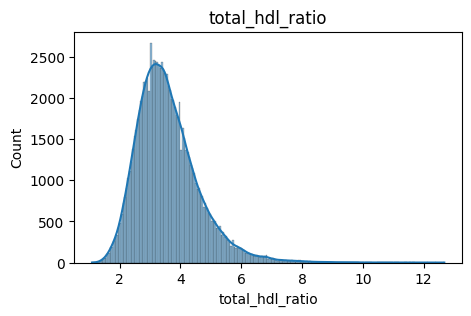

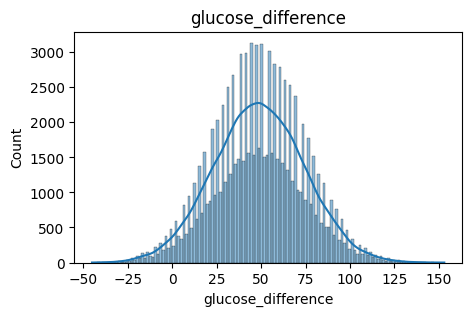

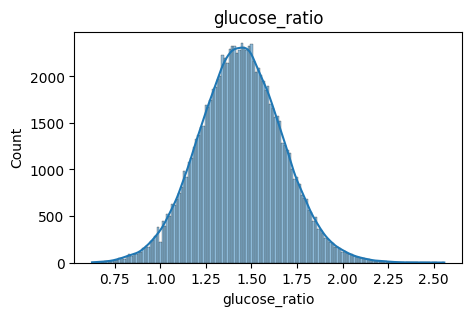

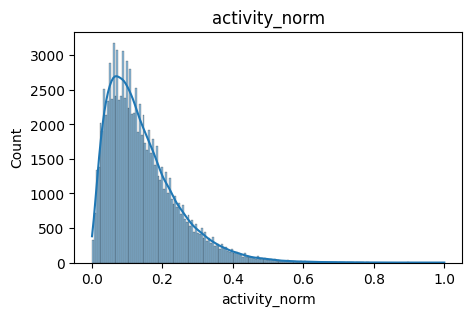

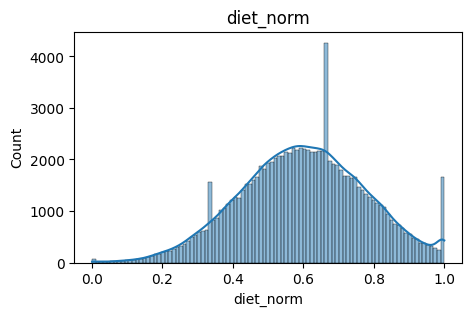

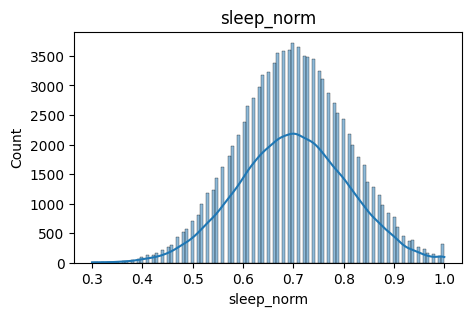

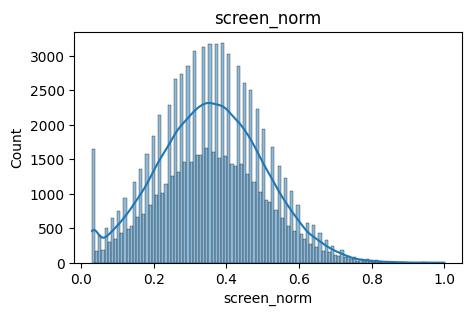

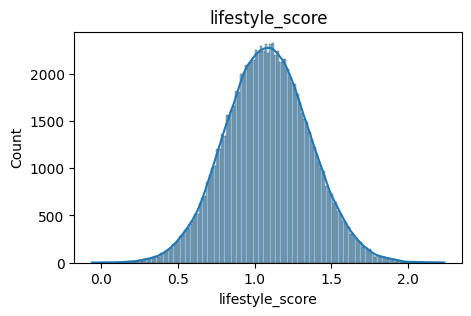

In [22]:
num_cols = F2.select_dtypes(include = 'number').columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sn.histplot(F2[col],kde = True)
    plt.title(col)
    plt.show()

# :- Boxplot for Outliers

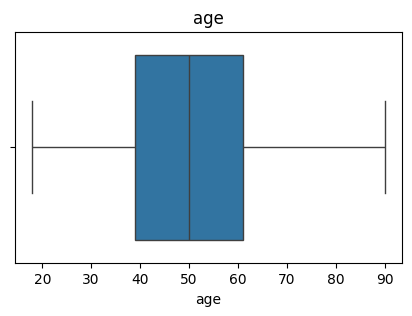

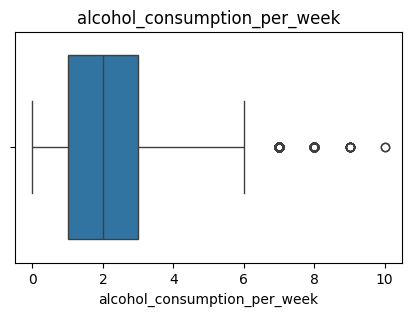

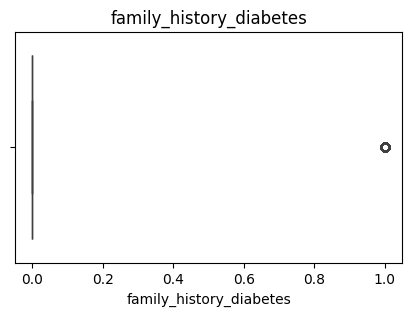

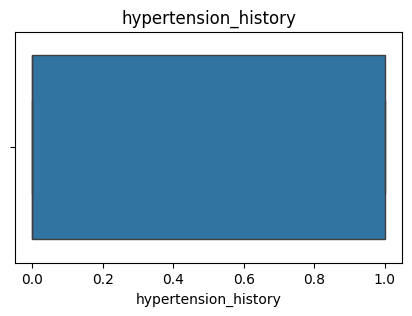

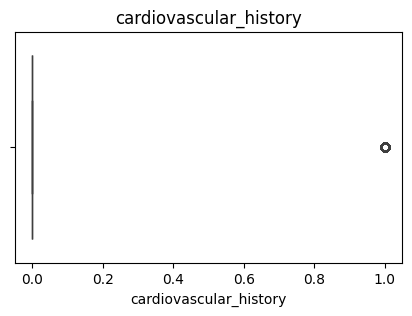

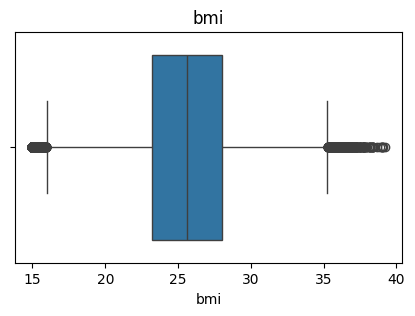

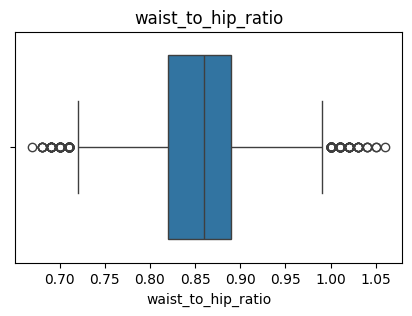

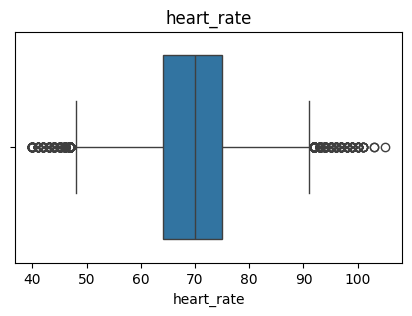

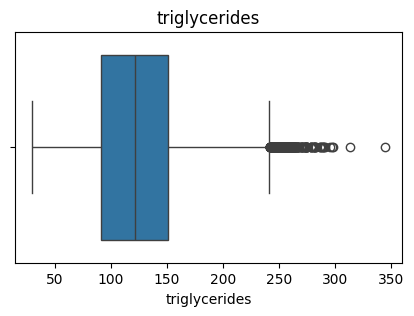

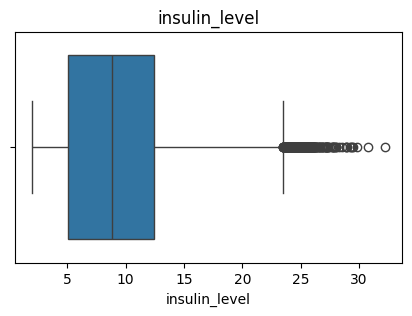

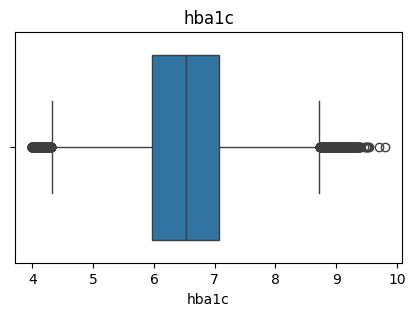

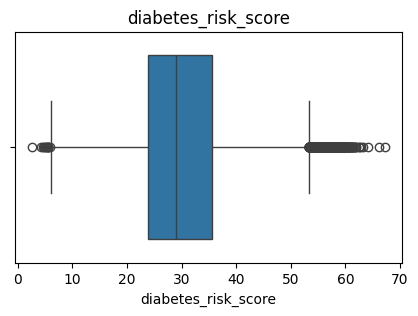

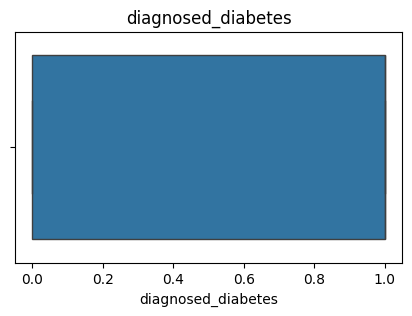

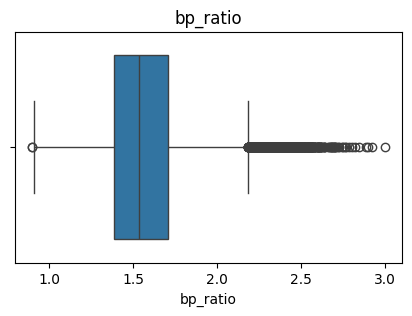

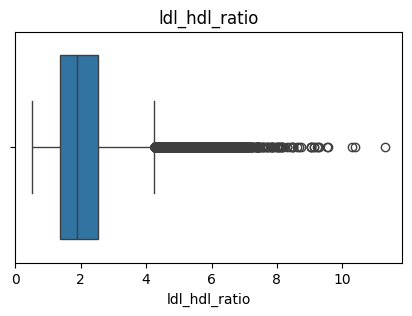

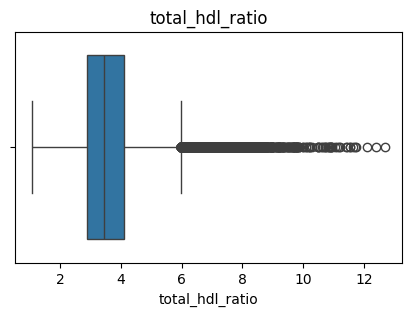

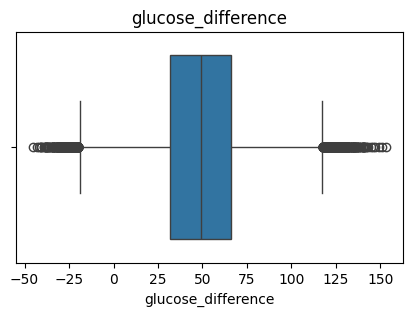

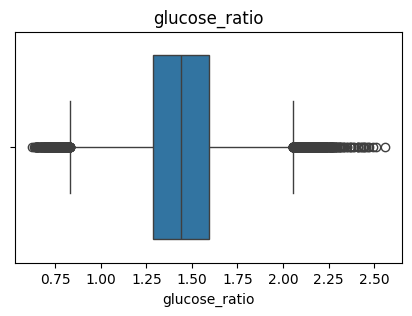

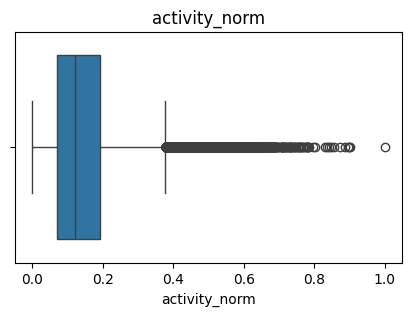

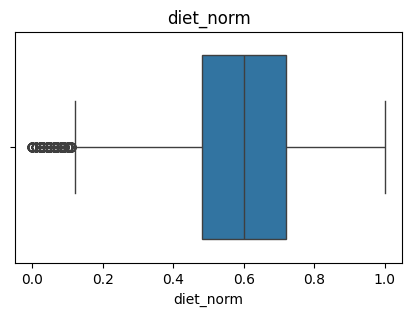

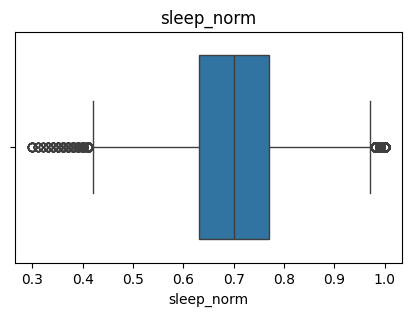

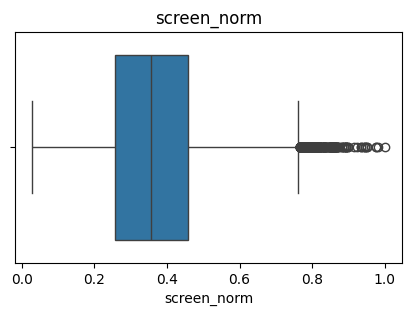

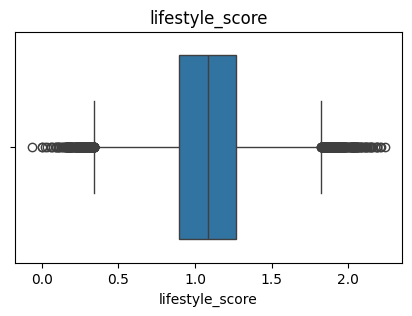

In [23]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sn.boxplot(x=F2[col])
    plt.title(col)
    plt.show()

# :- Realtionship with diabetes 

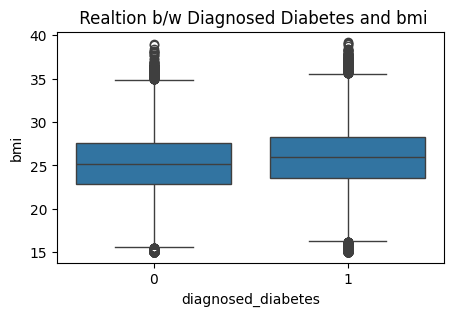

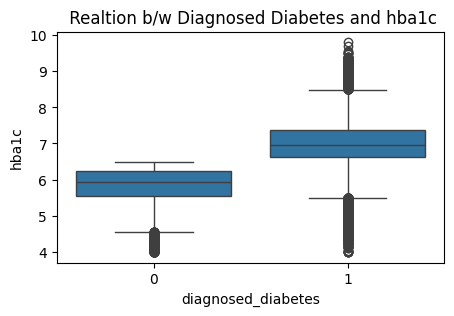

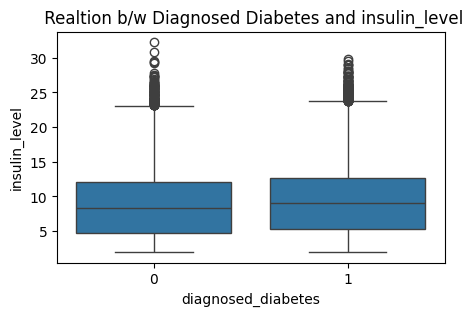

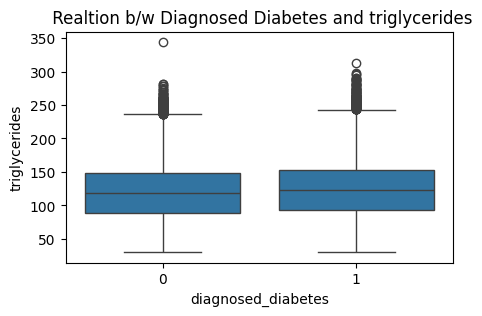

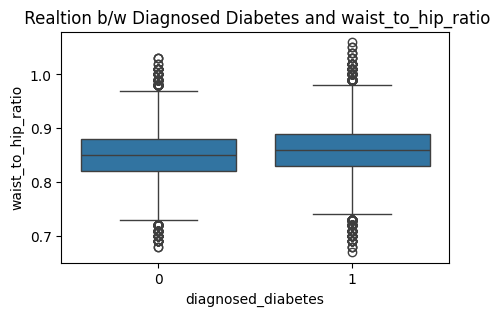

In [24]:
cols = ['bmi','hba1c','insulin_level','triglycerides','waist_to_hip_ratio']
for col in cols:
    plt.figure(figsize=(5,3))
    sn.boxplot(x = F2['diagnosed_diabetes'],y=F2[col])
    plt.title(f' Realtion b/w Diagnosed Diabetes and {col}')
    plt.show()

# Data Split

In [25]:
columns_Le = [
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status',
    'diabetes_stage'
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in columns_Le:
    F2[col] = le.fit_transform(F2[col])

In [26]:
X = F2.drop(
    columns=[
        'diagnosed_diabetes',
        'diabetes_stage'
    ]
)

y = F2['diagnosed_diabetes']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
y.shape

(100000,)

# Hypertunning 

In [30]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna

In [31]:

def objective(trial):

    model_type = trial.suggest_categorical(
        "model",
        ["xgboost", "lightgbm", "catboost"]
    )

    if model_type == "xgboost":

        model = XGBClassifier(
            n_estimators=trial.suggest_int(
                "xgb_n_estimators", 100, 500
            ),
            max_depth=trial.suggest_int(
                "xgb_max_depth", 3, 12
            ),
            learning_rate=trial.suggest_float(
                "xgb_learning_rate", 0.01, 0.3
            ),
            subsample=trial.suggest_float(
                "xgb_subsample", 0.6, 1.0
            ),
            colsample_bytree=trial.suggest_float(
                "xgb_colsample_bytree", 0.6, 1.0
            ),
            eval_metric="logloss",
            random_state=42
        )

    elif model_type == "lightgbm":

        model = LGBMClassifier(
            n_estimators=trial.suggest_int(
                "lgb_n_estimators", 100, 500
            ),
            max_depth=trial.suggest_int(
                "lgb_max_depth", 3, 12
            ),
            learning_rate=trial.suggest_float(
                "lgb_learning_rate", 0.01, 0.3
            ),
            num_leaves=trial.suggest_int(
                "lgb_num_leaves", 20, 300
            ),
            verbosity=-1,
            random_state=42
        )

    else:

        model = CatBoostClassifier(
            iterations=trial.suggest_int(
                "cat_iterations", 100, 500
            ),
            depth=trial.suggest_int(
                "cat_depth", 3, 10
            ),
            learning_rate=trial.suggest_float(
                "cat_learning_rate", 0.01, 0.3
            ),
            l2_leaf_reg=trial.suggest_float(
                "cat_l2_leaf_reg", 1, 10
            ),
            verbose=0,
            random_state=42
        )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

# :- RUNNING

In [32]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10,show_progress_bar=True)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-06-23 18:47:45,835] A new study created in memory with name: no-name-0713650a-21b0-4c4e-b4e4-62ec258666b2


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-23 18:48:13,954] Trial 0 finished with value: 0.9122581910578472 and parameters: {'model': 'xgboost', 'xgb_n_estimators': 421, 'xgb_max_depth': 12, 'xgb_learning_rate': 0.10698280657692891, 'xgb_subsample': 0.9066070644789292, 'xgb_colsample_bytree': 0.6423351769988376}. Best is trial 0 with value: 0.9122581910578472.
[I 2026-06-23 18:48:26,086] Trial 1 finished with value: 0.9122656115708816 and parameters: {'model': 'lightgbm', 'lgb_n_estimators': 110, 'lgb_max_depth': 11, 'lgb_learning_rate': 0.04820002620458236, 'lgb_num_leaves': 239}. Best is trial 1 with value: 0.9122656115708816.
[I 2026-06-23 18:48:31,305] Trial 2 finished with value: 0.9078658233308048 and parameters: {'model': 'lightgbm', 'lgb_n_estimators': 208, 'lgb_max_depth': 7, 'lgb_learning_rate': 0.28354739748649416, 'lgb_num_leaves': 33}. Best is trial 1 with value: 0.9122656115708816.
[I 2026-06-23 18:48:49,537] Trial 3 finished with value: 0.9106109280630937 and parameters: {'model': 'lightgbm', 'lgb_n_es

# :-Best Models

In [33]:
best_params = study.best_params

In [34]:
final_model = XGBClassifier(
    n_estimators=best_params["xgb_n_estimators"],
    max_depth=best_params["xgb_max_depth"],
    learning_rate=best_params["xgb_learning_rate"],
    subsample=best_params["xgb_subsample"],
    colsample_bytree=best_params["xgb_colsample_bytree"],
    eval_metric="logloss",
    random_state=42
)

final_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9066183105633447
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


# Evaluation

In [35]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# :- Accuracy, Precision, Recall, F1

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.91175
Precision: 0.9943546817208487
Recall   : 0.8568313343957058
F1 Score : 0.9204847501914674


# :- Classification Report

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      8077
           1       0.99      0.86      0.92     11923

    accuracy                           0.91     20000
   macro avg       0.91      0.92      0.91     20000
weighted avg       0.93      0.91      0.91     20000



# Confusion Matrix 

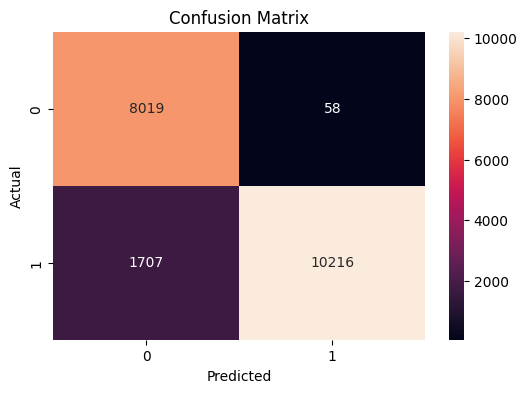

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# :- ROC Curve 

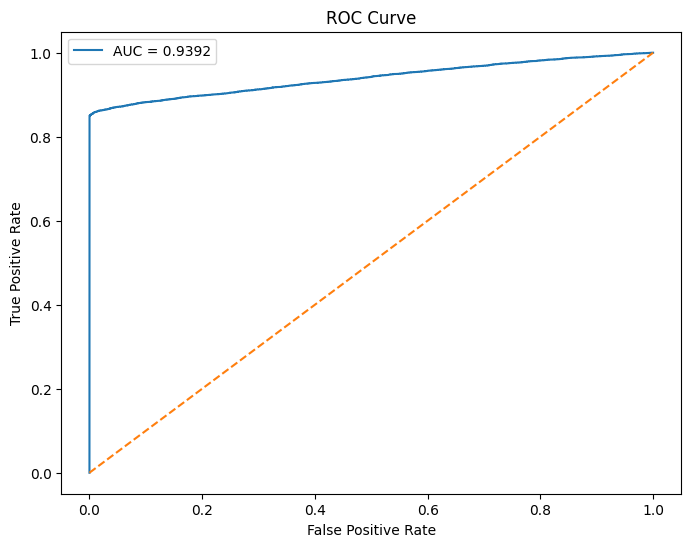

ROC-AUC Score: 0.9392287368357841


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)

# :- PR Curve

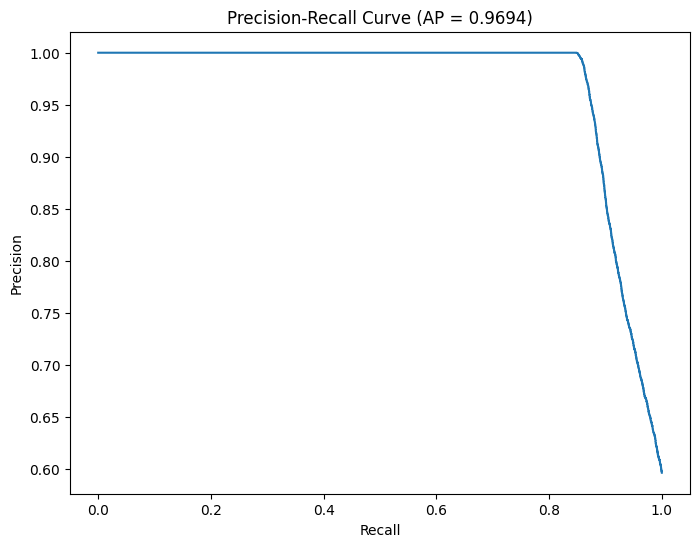

Average Precision Score: 0.9693628204478165


In [40]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.4f})")
plt.show()

print("Average Precision Score:", ap_score)

# Evaluation Summary

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9117
Precision: 0.9944
Recall: 0.8568
F1 Score: 0.9205
ROC-AUC: 0.9392


# Model Saving 

In [42]:
import joblib

joblib.dump(final_model, "best_diabetes_model.pkl")

['best_diabetes_model.pkl']